In [7]:
!pip install -q scikit-learn matplotlib numpy tensorflow

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

try:
    from sklearn.cluster import KMeans as SKKMeans
    SKLEARN_AVAILABLE = True
except Exception as e:
    SKLEARN_AVAILABLE = False
    print("scikit-learn not available:", e)

## K-Means: Math

Objective: minimize within-cluster sum of squares
$$
\min_{\{C_k\}, \{\mu_k\}} \sum_{k=1}^K \sum_{x_i \in C_k} \|x_i - \mu_k\|^2.
$$
Alternating updates: assign to nearest centroid, then recompute centroids as cluster means.

## Lloyd’s Algorithm for K-Means Clustering

Lloyd’s algorithm is the standard iterative refinement method used to compute the **k-means** clustering solution.  
It alternates between assigning samples to the nearest cluster centers and updating those centers based on current assignments.

---

### Objective

The algorithm seeks to minimize the **within-cluster sum of squared distances (WCSS)**, also called the **distortion function**:

$$
J = \sum_{j=1}^{k} \sum_{i \in \text{cluster } j} \| x_i - \mu_j \|^2
$$

where:

- $x_i$ is the *i*-th data point  
- $\mu_j$ is the centroid (mean) of cluster *j*  
- $k$ is the number of clusters

---

### Algorithm Steps

1. **Initialization**

   Choose $k$ initial cluster centers (randomly or using heuristics such as k-means++):
   $$
   \mu_1^{(0)}, \mu_2^{(0)}, \dots, \mu_k^{(0)}
   $$

2. **Assignment Step (E-step analog)**

   Assign each data point $x_i$ to the cluster whose center is closest in Euclidean distance:

   $$
   r_{ij} =
   \begin{cases}
   1, & \text{if } j = \arg\min_{\ell} \|x_i - \mu_\ell\|^2 \\
   0, & \text{otherwise}
   \end{cases}
   $$

   This forms a partition of the data into $k$ clusters.

3. **Update Step (M-step analog)**

   Recompute each cluster center as the mean of all points assigned to it:

   $$
   \mu_j = \frac{1}{N_j} \sum_{i: r_{ij}=1} x_i
   $$
   where $N_j = \sum_i r_{ij}$ is the number of points in cluster $j$.

4. **Convergence Check**

   Repeat steps (2) and (3) until one of the following holds:
   - Cluster assignments no longer change  
   - The reduction in $J$ between iterations falls below a threshold  
   - A maximum number of iterations is reached

---

### Interpretation

- Lloyd’s algorithm performs **coordinate descent** on $J$:  
  - The assignment step minimizes $J$ w.r.t. the cluster labels  
  - The update step minimizes $J$ w.r.t. the cluster centers

- The procedure **guarantees non-increasing distortion** at each iteration, but convergence is only to a **local minimum**, not necessarily the global optimum.

---

### Variance Perspective

Although Lloyd’s algorithm minimizes total squared distance, it does **not explicitly model or estimate variance parameters**.  
Each cluster is assumed to have **equal, spherical variance**.  
Thus, it can be viewed as the maximum-likelihood estimate of a mixture of $k$ isotropic Gaussians with shared variance:

$$
p(x \mid j) \sim \mathcal{N}(\mu_j, \sigma^2 I)
$$

For unequal or anisotropic variances, use **Gaussian Mixture Models (GMMs)** trained via the **Expectation-Maximization (EM)** algorithm.

---

### Summary

| Step | Description | Optimizes |
|------|--------------|------------|
| Initialization | Choose $k$ centers | – |
| Assignment | Assign each point to nearest center | Labels ($r_{ij}$) |
| Update | Compute new cluster means | Centers ($\mu_j$) |
| Repeat | Until convergence | Minimizes $J$ |

Lloyd’s algorithm is fast, simple, and effective for roughly spherical clusters,  
but it may perform poorly when clusters have unequal sizes, densities, or variances.

### Lloyd’s Algorithm and Cluster Variance

Lloyd’s algorithm (the standard k-means procedure) alternates:

1. **Assignment step:** assign each sample to the nearest center using $D$
2. **Update step:** update each center to the mean of its assigned samples

It minimizes the **within-cluster sum of squared distances (WCSS)**:

$$
J = \sum_{j=1}^k \sum_{i \in \text{cluster } j} \| X[i] - \mu_j \|^2
$$

which can also be written as:

$$
J = \sum_{j=1}^k N_j \cdot \text{Var}_j
$$

Thus, it *implicitly* minimizes a **weighted sum of cluster variances**,  
but it does **not explicitly estimate per-cluster variance parameters**.

All clusters are effectively treated as having **equal, spherical variance** (isotropic assumption).  
For unequal or anisotropic variances, use **Gaussian Mixture Models (EM)** instead.



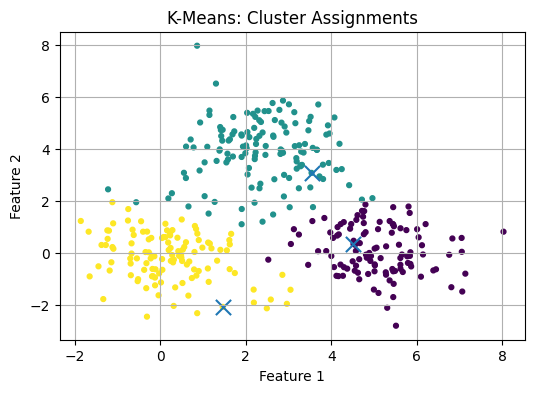

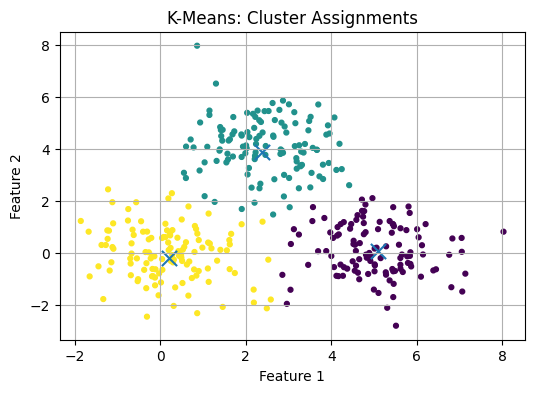

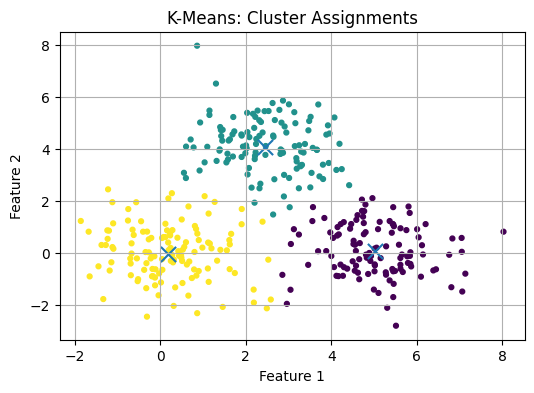

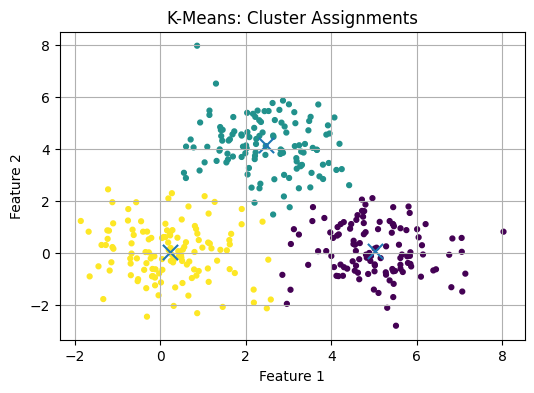

In [12]:
# Equivalent to sq_dists = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
def pairwise_sq_dists_loops(X: np.ndarray, centers: np.ndarray) -> np.ndarray:
    """
    Compute pairwise squared Euclidean distances between each row of X and each row of centers
    using explicit Python loops (no broadcasting).

    Parameters
    ----------
    X : (n_samples, n_features) array
    centers : (k, n_features) array

    Returns
    -------
    sq_dists : (n_samples, k) array
        sq_dists[i, j] = ||X[i] - centers[j]||^2
    """
    n, f = X.shape
    k = centers.shape[0]
    sq_dists = np.empty((n, k), dtype=np.result_type(X.dtype, centers.dtype))

    for i in range(n):
        xi = X[i]
        for j in range(k):
            diff = xi - centers[j]
            # squared Euclidean distance = dot(diff, diff)
            sq_dists[i, j] = np.dot(diff, diff)

    return sq_dists

def plot(X, labels, centers):
  plt.figure()
  plt.scatter(X[:, 0], X[:, 1], c=labels, s=12)
  plt.scatter(centers[:, 0], centers[:, 1], marker='x', s=120)
  plt.title("K-Means: Cluster Assignments")
  plt.xlabel("Feature 1")
  plt.ylabel("Feature 2")
  plt.show()

# === K-Means (From Scratch) ===
np.random.seed(1)

# 1) Generate a 2D dataset with 3 clusters
true_centers = np.array([[0, 0], [5, 0], [2.5, 4]])
points_per_cluster = 120
A = np.random.randn(points_per_cluster, 2) + true_centers[0]
B = np.random.randn(points_per_cluster, 2) + true_centers[1]
C = np.random.randn(points_per_cluster, 2) + true_centers[2]
X_km = np.vstack([A, B, C])

# 2) K-means via Lloyd's algorithm
def kmeans_from_scratch(X, K=3, max_iters=100, seed=0):
    # Randomly pick K points as initial centroids
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    centers = X[rng.choice(n, size=K, replace=False)]

    for _ in range(max_iters):
        # Compute squared distances to each center -> (n, K)
        sq_dists = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)

        # Assign to nearest center
        labels = np.argmin(sq_dists, axis=1)

        # Plot this iteration
        plot(X, labels, centers)

        # Update centers as mean of assigned points (if cluster empty, keep old center)
        new_centers = np.array([
            X[labels == k].mean(axis=0) if np.any(labels == k) else centers[k]
            for k in range(K)
        ])

        # If centers did not move much, stop
        if np.allclose(centers, new_centers):
            centers = new_centers
            break

        centers = new_centers

    return centers, labels

centers, labels = kmeans_from_scratch(X_km, K=3, max_iters=100, seed=123)


## Broadcasting Trick

### K-means Distance Computation and Broadcasting Summary

#### Goal

Given data $X \in \mathbb{R}^{n \times f}$ (with $n$ samples and $f$ features) and cluster centers $C \in \mathbb{R}^{k \times f}$ (with $k$ centers),  
we need the matrix $D \in \mathbb{R}^{n \times k}$ with entries

$$
D[i, j] = \| X[i, :] - C[j, :] \|^2
$$

to assign each sample to its nearest center.

---

### Broadcasting Trick (Vectorized NumPy)

A concise and fast way (no Python loops) is:

```python
sq_dists = ((X[:, None, :] - C[None, :, :]) ** 2).sum(axis=2)
```

#### Shapes

```
X[:, None, :]     → (n, 1, f)
C[None, :, :]     → (1, k, f)
subtraction       → (n, k, f)  [all pairwise differences]
square + sum      → (n, k)     [squared Euclidean distances]
```

#### Broadcasting Rule Applied

| Axis | Shapes Compared | Result | Meaning |
|------|------------------|---------|----------|
| 0 | $(n)$ vs $(1)$ | broadcast $1 \to n$ | repeat samples |
| 1 | $(1)$ vs $(k)$ | broadcast $1 \to k$ | repeat centers |
| 2 | $(f)$ vs $(f)$ | equal | feature dimension |

---

### Loop-based Equivalent (Explicit, No Broadcasting)

```python
for i in range(n):
    for j in range(k):
        diff = X[i] - C[j]
        D[i, j] = diff @ diff  # or np.dot(diff, diff)
```

This yields the same $D$ as the broadcasting version; it is easier to read but slower in Python.


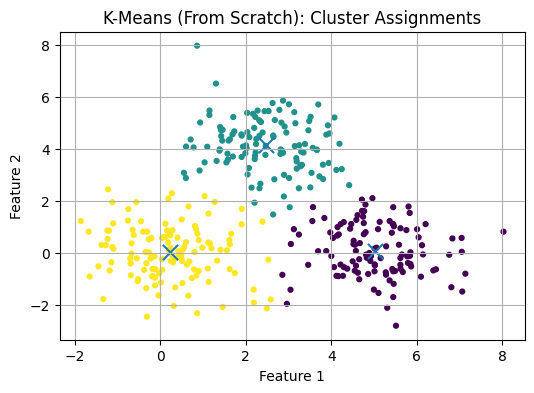

In [ ]:
# === K-Means (scikit-learn) ===
if SKLEARN_AVAILABLE:
    km = SKKMeans(n_clusters=3, n_init=10, random_state=42).fit(X_km)
    labs = km.labels_
    centers_skl = km.cluster_centers_

    plot(X_km, labels)
else:
    print("scikit-learn not available; skipping K-Means (scikit-learn).")


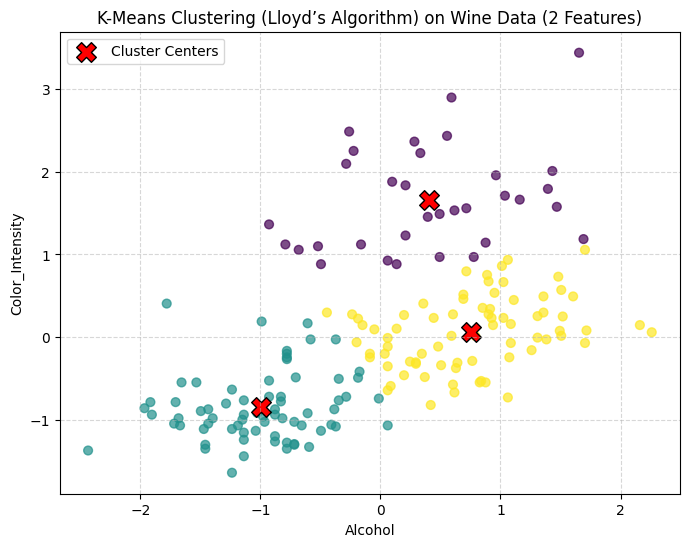

Assignments equal to KMeans labels: True


In [ ]:
# Real-world k-means clustering example on the UCI Wine dataset (two features only)
# This example selects just two chemical features so we can visualize the clusters directly.
# The algorithm uses Lloyd's method (implemented in scikit-learn's KMeans).

import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# -----------------------------
# 1) Load the dataset
# -----------------------------
wine = datasets.load_wine(as_frame=True)
X_df = wine.frame.drop(columns=["target"])
y_true = wine.target
feature_names = X_df.columns

# Select two features for visualization (feel free to change these)
selected_features = ["alcohol", "color_intensity"]
X = X_df[selected_features].values

# -----------------------------
# 2) Standardize the features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# 3) Run K-Means (Lloyd’s algorithm)
# -----------------------------
k = 3
kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
kmeans.fit(X_scaled)
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# -----------------------------
# 4) Plot clusters
# -----------------------------
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, s=40, cmap="viridis", alpha=0.7)
plt.scatter(
    centers[:, 0], centers[:, 1],
    marker="X", s=200, c="red", edgecolor="black", label="Cluster Centers"
)
plt.xlabel(selected_features[0].title())
plt.ylabel(selected_features[1].title())
plt.title("K-Means Clustering (Lloyd’s Algorithm) on Wine Data (2 Features)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# -----------------------------
# 5) Sanity check: distances and assignments
# -----------------------------
def pairwise_sq_dists_broadcasting(X_arr, C_arr):
    # Compute pairwise squared distances (n x k)
    return ((X_arr[:, None, :] - C_arr[None, :, :]) ** 2).sum(axis=2)

sq_dists = pairwise_sq_dists_broadcasting(X_scaled, centers)
assignments = np.argmin(sq_dists, axis=1)
print("Assignments equal to KMeans labels:", np.array_equal(assignments, labels))


## Nearest-Centroid Classification

Given a candidate node, identify its nearest centroid, or nearest neighbors, and have them vote on their nearest centroid.

Candidate point: [[13.  5.]]
Nearest centroid index: 2
Distance to that centroid: 0.7595


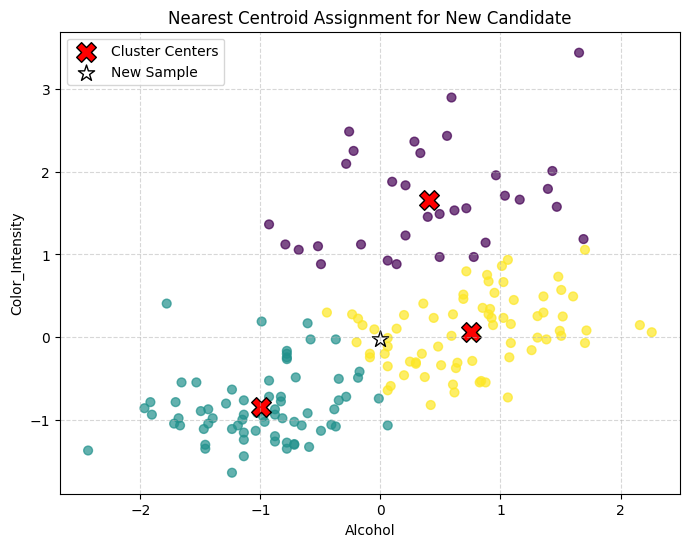

In [ ]:
# -----------------------------
# 6) Find the nearest centroid to a new candidate point
# -----------------------------
# Example candidate wine sample (raw feature values)
x_new = np.array([[13.0, 5.0]])  # [alcohol, color_intensity]

# Standardize it using the same scaler
x_new_scaled = scaler.transform(x_new)

# Compute distances to each k-means centroid
dists = np.linalg.norm(centers - x_new_scaled, axis=1)

# Find the nearest centroid index and its label
nearest_idx = np.argmin(dists)
print(f"Candidate point: {x_new}")
print(f"Nearest centroid index: {nearest_idx}")
print(f"Distance to that centroid: {dists[nearest_idx]:.4f}")

# Optional: visualize on the cluster plot
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, s=40, cmap="viridis", alpha=0.7)
plt.scatter(centers[:, 0], centers[:, 1], marker="X", s=200, c="red", edgecolor="black", label="Cluster Centers")
plt.scatter(x_new_scaled[:, 0], x_new_scaled[:, 1], c="white", edgecolor="black", s=150, marker="*", label="New Sample")
plt.xlabel(selected_features[0].title())
plt.ylabel(selected_features[1].title())
plt.title("Nearest Centroid Assignment for New Candidate")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


## K-Nearest Neighbors

The **k-Nearest Neighbors (k-NN)** classifier used here does *not* compute the closest centroid from k-means clustering.  Instead:

- **k-NN**: For each query point $x$, the algorithm finds the *k* closest training samples (using a chosen distance metric, typically Euclidean) and predicts the majority label among those neighbors.  
  - Decision boundaries are irregular and highly local.  
  - No centroids are used—only the raw training data.

- **Nearest-Centroid Classifier**: Each class is represented by the *mean* of its training samples (a supervised centroid).  
  - Prediction is made by assigning $x$ to the class whose mean vector is closest.  
  - Decision boundaries are linear between class centroids.

- **k-Means Prototypes**: In unsupervised learning, k-means finds cluster centers without knowing class labels. If you later assign labels to clusters (by majority vote), you can classify new points by the nearest cluster center.  
  - This resembles a centroid-based classifier, but the centroids are learned *without supervision* and may not align with true class boundaries.

**Summary:**
| Method | Uses Labels During Training? | Uses Actual Samples? | Decision Boundary | Notes |
|---------|------------------------------|----------------------|-------------------|-------|
| k-NN | ✅ Yes | ✅ Yes | Nonlinear, local | Votes among neighbors |
| Nearest Centroid | ✅ Yes | ❌ Uses class means only | Linear | Simple, global |
| k-Means Prototype | ❌ No | ❌ Uses cluster centers | Linear | Unsupervised proxy |

In short, **k-NN** bases classification on *neighboring samples*, not on *centroid proximity* as in k-means or nearest-centroid methods.


Best CV params: {'knn__metric': 'euclidean', 'knn__n_neighbors': 9, 'knn__weights': 'uniform'}
Best mean CV accuracy: 0.8873
Test accuracy: 0.7593

Classification report:
               precision    recall  f1-score   support

           0     0.6400    0.8889    0.7442        18
           1     0.8947    0.8095    0.8500        21
           2     0.8000    0.5333    0.6400        15

    accuracy                         0.7593        54
   macro avg     0.7782    0.7439    0.7447        54
weighted avg     0.7835    0.7593    0.7564        54



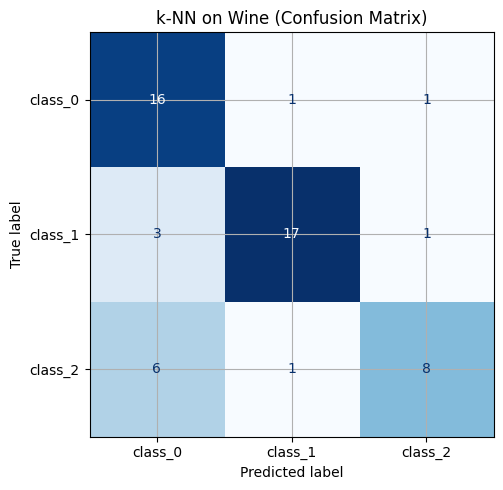

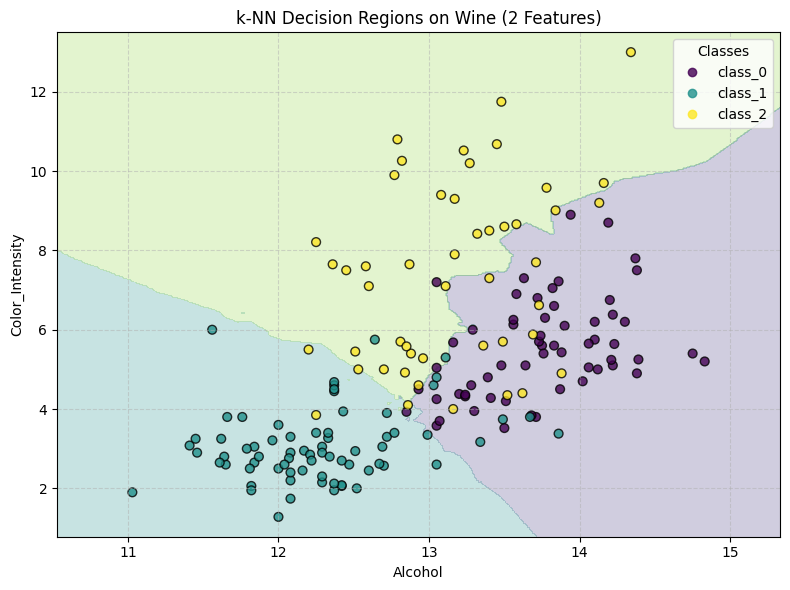

In [ ]:
# -----------------------------
# K-Nearest Neighbors Classification on Wine (same two features)
# -----------------------------
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Reuse the two features chosen earlier
X_cls = X_df[selected_features].values
y_cls = y_true

# 1) Train/validation split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.30, random_state=42, stratify=y_cls
)

# 2) Build a pipeline: Standardize -> kNN
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

# 3) Hyperparameter search over k, distance metric, and weighting
param_grid = {
    "knn__n_neighbors": [1, 3, 5, 7, 9, 11, 15],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(pipe, param_grid, cv=cv, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best CV params:", grid.best_params_)
print("Best mean CV accuracy:", round(grid.best_score_, 4))

# 4) Evaluate on the test set
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print("Test accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))

# 5) Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_cls))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine.target_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("k-NN on Wine (Confusion Matrix)")
plt.tight_layout()
plt.show()

# 6) Decision boundary over the two features (uses the trained pipeline)
#    We'll create a grid in the ORIGINAL feature scale; the pipeline will handle scaling internally.
f0_range = (X_cls[:, 0].min() - 0.5, X_cls[:, 0].max() + 0.5)
f1_range = (X_cls[:, 1].min() - 0.5, X_cls[:, 1].max() + 0.5)

xx, yy = np.meshgrid(
    np.linspace(*f0_range, 400),
    np.linspace(*f1_range, 400)
)
grid_points = np.c_[xx.ravel(), yy.ravel()]
zz = best_model.predict(grid_points).reshape(xx.shape)

plt.figure(figsize=(8, 6))
# Contourf of predicted classes
plt.contourf(xx, yy, zz, alpha=0.25, levels=np.arange(y_cls.max()+2)-0.5)
# Scatter the original samples (in original feature space)
scatter = plt.scatter(
    X_cls[:, 0], X_cls[:, 1],
    c=y_cls, s=40, cmap="viridis", edgecolor="k", alpha=0.8
)
plt.xlabel(selected_features[0].title())
plt.ylabel(selected_features[1].title())
plt.title("k-NN Decision Regions on Wine (2 Features)")
handles, _ = scatter.legend_elements()
plt.legend(handles, wine.target_names, title="Classes")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


### k-NN and Nearest Centroid Formulas

**k-Nearest Neighbors (majority vote)**

For a query point $ x $, let $ \mathcal{N}_k(x) $ be its set of $ k $ nearest neighbors with labels $ y_i $.  
The predicted label is the most frequent (mode) among them:

$$
\hat{y}(x) = \operatorname{mode}\{\, y_i : i \in \mathcal{N}_k(x) \,\}
$$

---

**Nearest Centroid Classifier**

For each class $ c $, define the centroid (mean vector):

$$
\boldsymbol{\mu}_c = \frac{1}{n_c} \sum_{i : y_i = c} \mathbf{x}_i
$$

Then, for a new sample $ \mathbf{x} $, assign the label of the closest centroid:

$$
\hat{y}(\mathbf{x}) = \arg\min_c \, \| \mathbf{x} - \boldsymbol{\mu}_c \|
$$

or equivalently, using squared distance:

$$
\hat{y}(\mathbf{x}) = \arg\min_c \, \| \mathbf{x} - \boldsymbol{\mu}_c \|^2
$$
